# Structured Features Collection — SEC EDGAR Company Facts API

Fetches FY2021 10-K financial fundamentals for all 332 companies in the modeling dataset using the SEC EDGAR Company Facts API (`https://data.sec.gov/api/xbrl/companyfacts/`).

**Why FY2021?** The ESG ratings in the dataset have `last_processing_date` in April 2022, meaning they are based on FY2021 10-K filings — the same filings we extracted text from. Using FY2021 financials keeps features and labels temporally aligned.

**Features collected:**
- `total_assets` — primary size indicator
- `total_revenue` — revenue scale (with multi-tag fallback)
- `net_income` — profitability
- `long_term_debt` — financial leverage
- `stockholders_equity` — book value
- `operating_income` — operational performance
- `cash_and_equivalents` — liquidity
- `public_float` — market cap proxy (from DEI namespace)

**Derived features:**
- `debt_to_assets` = long_term_debt / total_assets
- `profit_margin` = net_income / total_revenue
- `return_on_equity` = net_income / stockholders_equity

Output: `data/structured_features/sec_fundamentals.csv`

In [2]:
import time
import json
import requests
import numpy as np
import pandas as pd
from pathlib import Path

## 1. Load the 332-company dataset and get CIK mapping

In [3]:
DATA_DIR = Path('../data')

# Tickers in our modeling dataset
merged = pd.read_csv(DATA_DIR / 'finbert_features' / 'merged_features_labels.csv')
modeling_tickers = set(merged['ticker'].str.upper())
print(f'Modeling companies: {len(modeling_tickers)}')

# CIK lookup from full ESG dataset
esg = pd.read_csv(DATA_DIR / 'ESG_data_cleaned.csv')
esg['ticker'] = esg['ticker'].str.upper()
ticker_to_cik = esg.set_index('ticker')['cik'].to_dict()

# Build the fetch list: (ticker, cik)
fetch_list = []
missing_cik = []
for ticker in sorted(modeling_tickers):
    cik = ticker_to_cik.get(ticker)
    if cik:
        fetch_list.append((ticker, int(cik)))
    else:
        missing_cik.append(ticker)

print(f'Tickers with CIK: {len(fetch_list)}')
print(f'Tickers missing CIK: {missing_cik}')

Modeling companies: 332
Tickers with CIK: 332
Tickers missing CIK: []


## 2. Define concept extraction helpers

The EDGAR Company Facts API returns every XBRL-tagged value a company has ever filed. We extract the **FY2021 annual 10-K** value (form=`10-K`, fy=2021, fp=`FY`). When multiple entries match, we take the most recently filed one (latest `filed` date).

Revenue uses a priority fallback list because companies tag revenue under different XBRL concepts depending on their industry.

In [4]:
HEADERS = {'User-Agent': 'Syracuse University ML research project student@syr.edu'}

# Revenue has many valid XBRL tags; try them in priority order
REVENUE_CONCEPTS = [
    'Revenues',
    'RevenueFromContractWithCustomerExcludingAssessedTax',
    'RevenueFromContractWithCustomerIncludingAssessedTax',
    'SalesRevenueNet',
    'SalesRevenueGoodsNet',
    'RevenuesNetOfInterestExpense',
    'InterestAndDividendIncomeOperating',  # banks/financials
    'HealthCareOrganizationRevenue',       # healthcare
]

def get_annual_value(facts_ns, concept, unit='USD', fy=2021):
    """
    Extract the FY annual 10-K value for a given concept from a facts namespace dict.
    Returns None if not found.
    """
    if concept not in facts_ns:
        return None
    entries = facts_ns[concept].get('units', {}).get(unit, [])
    # Filter to FY annual 10-K filings for the target fiscal year
    candidates = [
        e for e in entries
        if e.get('form') == '10-K' and e.get('fy') == fy and e.get('fp') == 'FY'
    ]
    if not candidates:
        # Fallback: any 10-K entry for that fy (some companies omit fp)
        candidates = [e for e in entries if e.get('form') == '10-K' and e.get('fy') == fy]
    if not candidates:
        return None
    # Take the most recently filed entry
    candidates.sort(key=lambda e: e.get('filed', ''), reverse=True)
    return candidates[0]['val']


def get_revenue(gaap, fy=2021):
    """Try revenue concepts in priority order, return first match."""
    for concept in REVENUE_CONCEPTS:
        val = get_annual_value(gaap, concept, unit='USD', fy=fy)
        if val is not None:
            return val
    return None


def fetch_company_facts(cik):
    """Fetch EDGAR Company Facts JSON for a given CIK. Returns None on error."""
    url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik:010d}.json'
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        return resp.json()
    except Exception as e:
        return None


def extract_features(data, fy=2021):
    """Extract all target features from a Company Facts JSON response."""
    gaap = data.get('facts', {}).get('us-gaap', {})
    dei  = data.get('facts', {}).get('dei', {})

    total_assets       = get_annual_value(gaap, 'Assets',                              fy=fy)
    total_revenue      = get_revenue(gaap, fy=fy)
    net_income         = get_annual_value(gaap, 'NetIncomeLoss',                        fy=fy)
    long_term_debt     = get_annual_value(gaap, 'LongTermDebt',                         fy=fy)
    stockholders_eq    = get_annual_value(gaap, 'StockholdersEquity',                   fy=fy)
    operating_income   = get_annual_value(gaap, 'OperatingIncomeLoss',                  fy=fy)
    cash_equiv         = get_annual_value(gaap, 'CashAndCashEquivalentsAtCarryingValue', fy=fy)
    public_float       = get_annual_value(dei,  'EntityPublicFloat', unit='USD',         fy=fy)

    return {
        'total_assets':       total_assets,
        'total_revenue':      total_revenue,
        'net_income':         net_income,
        'long_term_debt':     long_term_debt,
        'stockholders_equity': stockholders_eq,
        'operating_income':   operating_income,
        'cash_and_equivalents': cash_equiv,
        'public_float':       public_float,
    }

## 3. Fetch all 332 companies

In [5]:
records = []
failures = []
no_fy_data = []

for i, (ticker, cik) in enumerate(fetch_list):
    data = fetch_company_facts(cik)
    if data is None:
        failures.append(ticker)
        records.append({'ticker': ticker, **{k: None for k in [
            'total_assets', 'total_revenue', 'net_income', 'long_term_debt',
            'stockholders_equity', 'operating_income', 'cash_and_equivalents', 'public_float'
        ]}})
    else:
        feats = extract_features(data, fy=2021)
        records.append({'ticker': ticker, **feats})
        # Track companies where we got nothing at all
        if all(v is None for v in feats.values()):
            no_fy_data.append(ticker)

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(fetch_list)} fetched...')

    time.sleep(0.12)  # ~8 req/s, within EDGAR's limit

print(f'\nDone. Failures (HTTP error): {len(failures)} — {failures}')
print(f'No FY2021 data at all:      {len(no_fy_data)} — {no_fy_data}')

  50/332 fetched...
  100/332 fetched...
  150/332 fetched...
  200/332 fetched...
  250/332 fetched...
  300/332 fetched...

Done. Failures (HTTP error): 0 — []
No FY2021 data at all:      4 — ['ACGL', 'AIRT', 'AKTX', 'BBY']


## 4. Build DataFrame and inspect coverage

In [6]:
raw = pd.DataFrame(records)
raw = raw.set_index('ticker')

print('Raw coverage (non-null count per feature):')
print(raw.notna().sum().to_string())
print(f'\nTotal companies: {len(raw)}')

Raw coverage (non-null count per feature):
total_assets            328
total_revenue           314
net_income              301
long_term_debt          162
stockholders_equity     307
operating_income        268
cash_and_equivalents    296
public_float            325

Total companies: 332


## 5. Derive ratio features

In [7]:
df = raw.copy()

df['debt_to_assets'] = np.where(
    df['total_assets'].notna() & (df['total_assets'] != 0) & df['long_term_debt'].notna(),
    df['long_term_debt'] / df['total_assets'],
    np.nan
)

df['profit_margin'] = np.where(
    df['total_revenue'].notna() & (df['total_revenue'] != 0) & df['net_income'].notna(),
    df['net_income'] / df['total_revenue'],
    np.nan
)

df['return_on_equity'] = np.where(
    df['stockholders_equity'].notna() & (df['stockholders_equity'] != 0) & df['net_income'].notna(),
    df['net_income'] / df['stockholders_equity'],
    np.nan
)

print('Coverage after deriving ratios:')
print(df.notna().sum().to_string())

Coverage after deriving ratios:
total_assets            328
total_revenue           314
net_income              301
long_term_debt          162
stockholders_equity     307
operating_income        268
cash_and_equivalents    296
public_float            325
debt_to_assets          162
profit_margin           281
return_on_equity        287


## 6. Log-transform size features

Assets, revenue, debt, cash, and public float span many orders of magnitude across companies. Log-transforming (with a sign-preserving approach for negative values) normalises these before modeling.

In [8]:
SIZE_FEATURES = ['total_assets', 'total_revenue', 'long_term_debt',
                 'cash_and_equivalents', 'public_float', 'stockholders_equity']

for col in SIZE_FEATURES:
    # log1p on absolute value, restore sign — handles near-zero and negative equity
    df[f'log_{col}'] = np.sign(df[col]) * np.log1p(df[col].abs())

print('Log-transformed columns added.')
df[['total_assets', 'log_total_assets', 'total_revenue', 'log_total_revenue']].describe()

Log-transformed columns added.


,total_assets,log_total_assets,total_revenue,log_total_revenue
count,3.280000e+02,328.000000,3.140000e+02,314.000000
mean,5.952002e+10,22.589462,1.694175e+10,21.355667
std,2.388262e+11,2.602600,3.507441e+10,4.022661
min,1.894061e+06,14.454234,0.000000e+00,0.000000
25%,1.801832e+09,21.312006,9.034398e+08,20.620743
50%,1.065050e+10,23.088872,5.690450e+09,22.461974
75%,3.641248e+10,24.318177,1.549843e+10,23.463979
max,2.819627e+12,28.667626,2.805220e+11,26.359918


## 7. Distribution plots

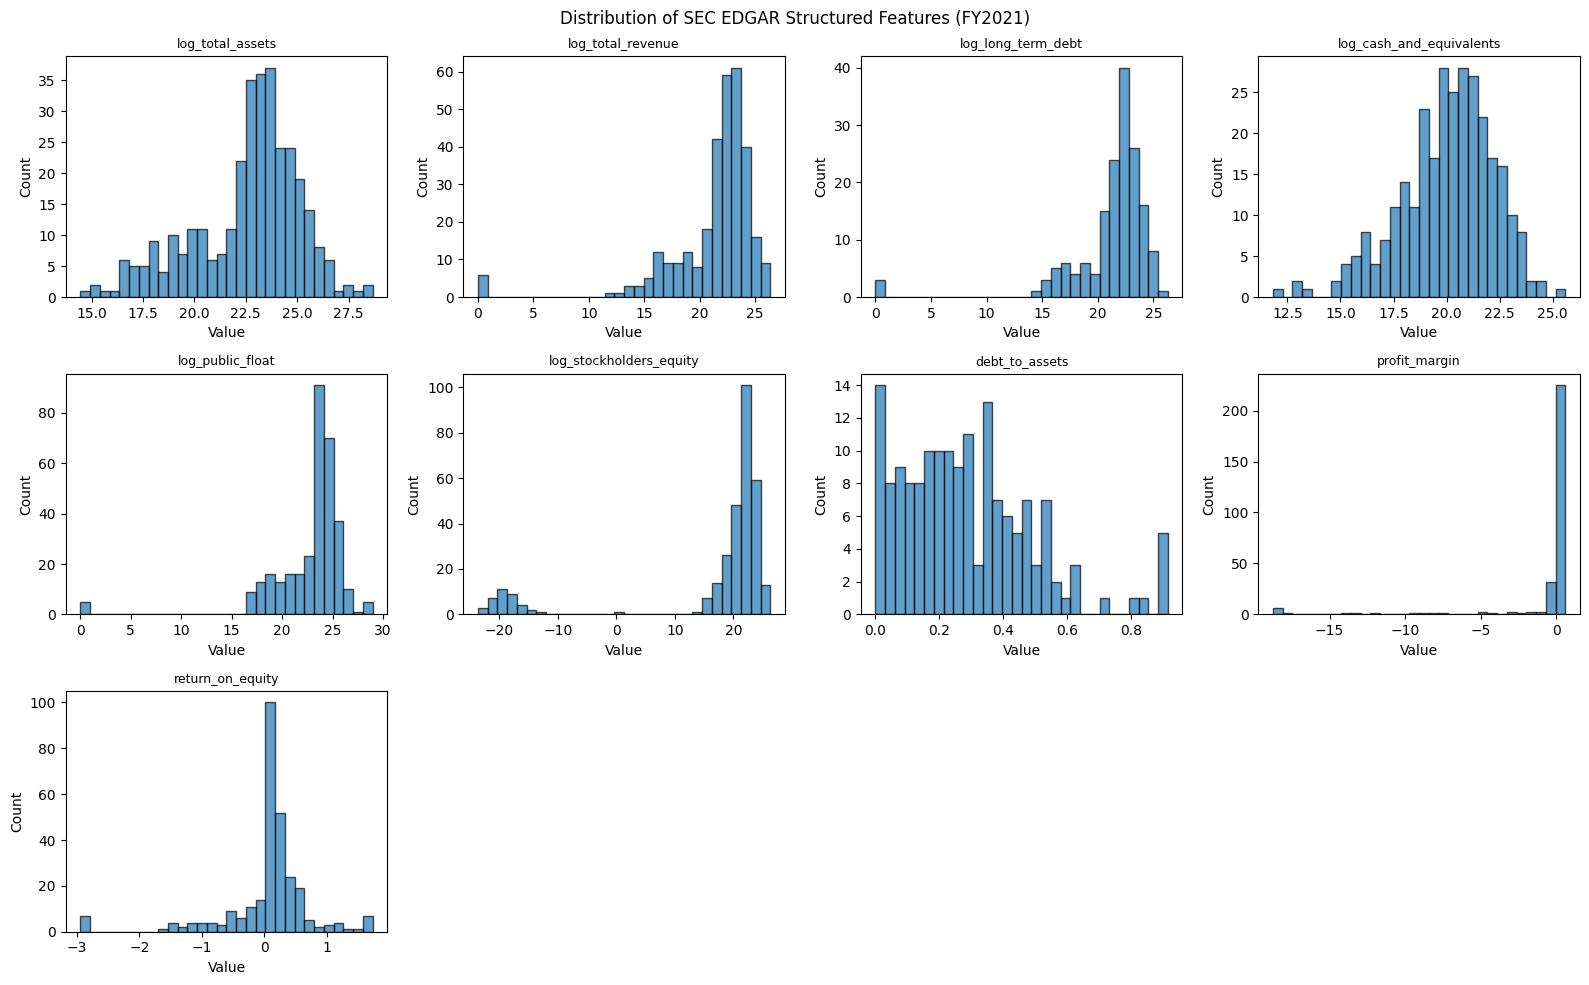

In [9]:
import matplotlib.pyplot as plt

log_cols = [c for c in df.columns if c.startswith('log_')]
ratio_cols = ['debt_to_assets', 'profit_margin', 'return_on_equity']
plot_cols = log_cols + ratio_cols

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    vals = df[col].dropna()
    # Clip ratio extremes for display
    if col in ratio_cols:
        vals = vals.clip(vals.quantile(0.02), vals.quantile(0.98))
    ax.hist(vals, bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

# Hide unused subplots
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of SEC EDGAR Structured Features (FY2021)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Correlation with ESG scores

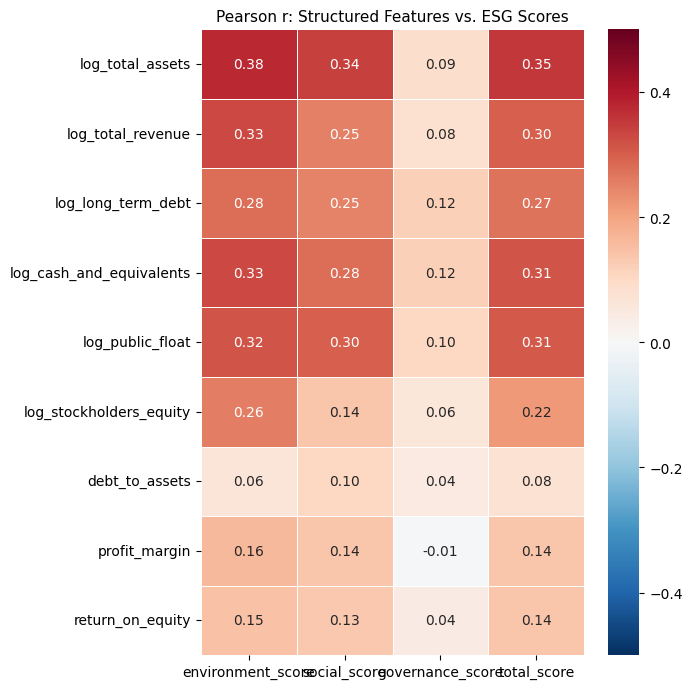

In [10]:
import seaborn as sns

targets = ['environment_score', 'social_score', 'governance_score', 'total_score']

# Merge in ESG targets
labels = merged[['ticker'] + targets].copy()
labels['ticker'] = labels['ticker'].str.upper()
labels = labels.set_index('ticker')

combined = df.join(labels, how='inner')

structured_cols = log_cols + ratio_cols
corr = combined[structured_cols + targets].corr().loc[structured_cols, targets]

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax
)
ax.set_title('Pearson r: Structured Features vs. ESG Scores', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Save to CSV

In [11]:
OUT_PATH = DATA_DIR / 'structured_features' / 'sec_fundamentals.csv'
df.reset_index().to_csv(OUT_PATH, index=False)
print(f'Saved {len(df)} companies × {len(df.columns)} features to {OUT_PATH}')
print('Columns:', df.columns.tolist())

Saved 332 companies × 17 features to ..\data\structured_features\sec_fundamentals.csv
Columns: ['total_assets', 'total_revenue', 'net_income', 'long_term_debt', 'stockholders_equity', 'operating_income', 'cash_and_equivalents', 'public_float', 'debt_to_assets', 'profit_margin', 'return_on_equity', 'log_total_assets', 'log_total_revenue', 'log_long_term_debt', 'log_cash_and_equivalents', 'log_public_float', 'log_stockholders_equity']


## 10. Missing value summary

Features with high missingness will need imputation (industry-median) before merging into the modeling pipeline.

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
summary = summary[summary['missing_count'] > 0]

print('Features with missing values:')
print(summary.to_string())

print(f'\nCompanies with ALL features present: {df.notna().all(axis=1).sum()}')
print(f'Companies with ANY feature missing:  {df.isna().any(axis=1).sum()}')

Features with missing values:
                          missing_count  missing_pct
long_term_debt                      170         51.2
log_long_term_debt                  170         51.2
debt_to_assets                      170         51.2
operating_income                     64         19.3
profit_margin                        51         15.4
return_on_equity                     45         13.6
log_cash_and_equivalents             36         10.8
cash_and_equivalents                 36         10.8
net_income                           31          9.3
stockholders_equity                  25          7.5
log_stockholders_equity              25          7.5
log_total_revenue                    18          5.4
total_revenue                        18          5.4
log_public_float                      7          2.1
public_float                          7          2.1
total_assets                          4          1.2
log_total_assets                      4          1.2

Companies with 